In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Импортируем файлы для анализа и сразу объединяем их в один датасет
json_url = "https://drive.google.com/uc?export=download&id=1ijDCI1iqn4_M5wuLplUTG5i2kJQ8wP2v"
clients_data = pd.read_json(json_url)

csv_url = f"https://docs.google.com/spreadsheets/d/1x_LbKww4KtJmfVHn0s4sY6k7E3SQEpKA/export?format=csv&gid=692328409"
transactions_data = pd.read_csv(csv_url)

In [3]:
# Переименовываем колонку для дальнейшего слияния
clients_data = clients_data.rename(columns={'id': 'client_id'})

# Объединяем все данные в один датафрейм
df = transactions_data.merge(
    clients_data,
    on='client_id',     
    how='left'           
)

### Предварительный анализ данных

In [4]:
# Выведем первые 5 строк данных
df.head()

,transaction_id,client_id,transaction_date,service,amount,payment_method,city,consultant,age,gender,net_worth
0,ff36597c-df41-44a0-9f46-6aa1fe615270,1ec5ab91-fdd0-4925-a221-f0c4e04fe0e7,2025-01-04 00:02:20,Структурирование капитала,"55838,05979",Банковский перевод,North Patrickport,Cheryl Waller,41.0,Мужчина,2514729.46
1,0d5263ec-413d-44d9-a9d3-a996e3a56b05,c940f45c-d29b-439a-8fa3-f75018cef528,2025-03-10 17:16:50,Структурирование капитала,"37514,80921",Неизвестно,New Zacharyport,Frank Pollard,28.0,Мужчина,566568.29
2,5e9a8978-df1c-483f-a53b-16149c93f11e,cfa21d7e-8499-43d0-9dfb-f4a1b94ce44c,2025-02-13 19:43:49,Структурирование капитала,"21022,14687",Неизвестно,Port Michellemouth,Alexandra Meyer,55.0,Женщина,1896001.28
3,524031ea-56e2-410a-aee2-e8fc6ae3fbc5,NaN,2025-03-02 03:14:10,Финансовое планирование,"2313,980219",Неизвестно,Erichaven,Patricia Haas,38.0,Женщина,4538759.60
4,421aaf04-c97d-42ac-b35f-09a56bbaf910,3f43d7bc-37f0-4535-8391-51702d6ff81e,2025-03-18 21:00:36,Структурирование капитала,"5636,586955",Неизвестно,Bondstad,Melissa Pena,31.0,Мужчина,4865849.92


In [5]:
# Узнаем больше о количестве строк и признаков в файле
df.shape

(10000, 11)

In [6]:
# Узнаем больше о типах данных в датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    9526 non-null   object 
 1   client_id         9798 non-null   object 
 2   transaction_date  10000 non-null  object 
 3   service           10000 non-null  object 
 4   amount            9540 non-null   object 
 5   payment_method    10000 non-null  object 
 6   city              10000 non-null  object 
 7   consultant        10000 non-null  object 
 8   age               9017 non-null   float64
 9   gender            6681 non-null   object 
 10  net_worth         9525 non-null   float64
dtypes: float64(2), object(9)
memory usage: 859.5+ KB


In [7]:
# Выведем статистическую информацию по датасету
df.describe()

,age,net_worth
count,9017.000000,9.525000e+03
mean,40.006543,2.544551e+06
std,11.695195,1.445574e+06
min,20.000000,1.021397e+04
25%,30.000000,1.291466e+06
50%,39.000000,2.540861e+06
75%,50.000000,3.813966e+06
max,60.000000,4.999428e+06


In [8]:
# Выведем количество пропущенных значений по столбцам
missing = df.isnull().sum()
missing

transaction_id       474
client_id            202
transaction_date       0
service                0
amount               460
payment_method         0
city                   0
consultant             0
age                  983
gender              3319
net_worth            475
dtype: int64

В ходе предварительного анализа данных были выявлены пропуски датасете. Отсутствуют значения в полях transaction_id (474 пропуска), client_id (202 пропуска) и amount (460 пропусков). Поскольку все три поля являются критически важными для анализа — идентификатор транзакции, ключ связи с клиентом и сумма операции — принято решение удалить строки с пропусками в этих колонках.
Суммарно это затронет около 10-11% записей, что является допустимым уровнем потерь и не повлияет на показательность выборки.

В данных клиентов обнаружены пропуски в полях age (983 пропуска), gender (3319 пропусков) и net_worth (475 пропусков). Для поля gender, где отсутствует более трети значений, принято решение удалить колонку полностью, так как заполнение модой или удаление строк внесёт существенное смещение в данные. Пропуски в полях age и net_worth будут заполнены медианными значениями. Такой подход выбран потому, что медиана устойчива к выбросам и позволяет сохранить объем данных без искажения распределения.


### Предобработка данных

In [9]:
# Удалим пропущенные значения в столбцах
df = df.dropna(subset=['transaction_id', 'client_id', 'amount'])

# Удалим даты с неправильным форматом
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
df = df.dropna(subset=['transaction_date'])

# Удалим дубликаты
df = df.drop_duplicates(subset=['transaction_id'], keep='first')

# Уберем неизвестные значения категориальных переменных
df['city'] = df['city'].replace(['Неизвестный город', 'Unknown', 'nan'], np.nan)
df['consultant'] = df['consultant'].replace(['Неизвестный консультант', 'Unknown', 'nan'], np.nan)

# Удалим столбец пол
df = df.drop(columns=['gender'])

# Заполним пропуски возраста и стоимости активов медианными значениями
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age)

median_net_worth = df['net_worth'].median()
df['net_worth'] = df['net_worth'].fillna(median_net_worth)

# Преобразуем amount к числовому типу (заменяем запятую на точку)
df['amount'] = df['amount'].astype(str).str.replace(',', '.', regex=False)
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')

# Удалим отрицательные amount
df = df[df['amount'] > 0]

# Преобразуем net_worth к числовому типу
df['net_worth'] = pd.to_numeric(df['net_worth'], errors='coerce')

# Удалим строки где после конвертации появились пропуски
df = df.dropna(subset=['amount', 'net_worth'])

# Функция для расчета границ IQR
def get_iqr_bounds(series, multiplier=3.0):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    return lower, upper

# Получаем границы
amount_lower, amount_upper = get_iqr_bounds(df['amount'])
net_worth_lower, net_worth_upper = get_iqr_bounds(df['net_worth'])

# Удаляем выбросы
df = df[
    (df['amount'] >= amount_lower) & (df['amount'] <= amount_upper) &
    (df['net_worth'] >= net_worth_lower) & (df['net_worth'] <= net_worth_upper)
]


In [10]:
# Выводим форму датафрейма после очистки
df.shape

(8005, 10)

В данном разделе мы почистили данные и убрали ненужный столбец gender и ~2000 строк, не подходящих для дальнейших исследований

### Основной анализ данных

In [14]:
# Топ-5 наиболее популярных услуг по количеству заказов
top_5_services = df['service'].value_counts().head(5).reset_index()
top_5_services.columns = ['service', 'count']

# Средняя сумма транзакций по каждому городу
avg_amount_by_city = df.groupby('city')['amount'].mean().reset_index()
avg_amount_by_city.columns = ['city', 'avg_amount']
avg_amount_by_city = avg_amount_by_city.sort_values('avg_amount', ascending=False)

# Услуга с наибольшей выручкой
revenue_by_service = df.groupby('service')['amount'].sum().reset_index()
revenue_by_service.columns = ['service', 'total_revenue']
revenue_by_service = revenue_by_service.sort_values('total_revenue', ascending=False)

# Процент транзакций по способам оплаты
payment_method_pct = df['payment_method'].value_counts(normalize=True) * 100
payment_method_pct = payment_method_pct.reset_index()
payment_method_pct.columns = ['payment_method', 'percentage']

# Выручка за последний месяц
max_date = df['transaction_date'].max()
last_month_start = max_date - timedelta(days=30)
revenue_last_month = df[df['transaction_date'] >= last_month_start]['amount'].sum()

# Категоризация
def categorize_net_worth(net_worth):
    """Функция для категоризации по уровню активов"""
    if net_worth < 100000:
        return 'Низкий капитал'
    elif net_worth <= 1000000:
        return 'Средний капитал'
    else:
        return 'Высокий капитал'

# Применяем категоризацию
df['wealth_category'] = df['net_worth'].apply(categorize_net_worth)

# Анализ выручки по категориям клиентов
revenue_by_wealth = df.groupby('wealth_category').agg({
    'amount': ['sum', 'mean', 'count']
}).round(2)

revenue_by_wealth.columns = ['total_revenue', 'avg_transaction', 'transaction_count']
revenue_by_wealth = revenue_by_wealth.reset_index()

In [15]:
# Топ-5 услуг
top_5_services

,service,count
0,Инвестиционное консультирование,1953
1,Управление активами,1605
2,Финансовое планирование,1241
3,Налоговое планирование,1216
4,Структурирование капитала,1196


In [16]:
# Средняя сумма по городам
avg_amount_by_city

,city,avg_amount
9,East Rachelmouth,57472.974698
41,Port Michellemouth,57147.046359
25,Michellehaven,55749.584972
30,New Tommyborough,54873.148507
34,North Lauriebury,54052.564197
31,New Zacharyport,53437.511038
47,Trevinoberg,52417.533717
17,Kaneburgh,52315.357900
22,Lake Tina,52188.311380
19,Krystalland,52172.458047


In [17]:
# Выручка по услугам
revenue_by_service

,service,total_revenue
0,Инвестиционное консультирование,9.749006e+07
4,Управление активами,7.868798e+07
5,Финансовое планирование,6.207674e+07
1,Налоговое планирование,5.995544e+07
3,Структурирование капитала,5.785634e+07
2,Неизвестная услуга,4.076838e+07


In [18]:
# Процент по способам оплаты
payment_method_pct

,payment_method,percentage
0,Кредитная карта,40.037477
1,Банковский перевод,34.615865
2,Неизвестно,10.143660
3,Наличные,9.931293
4,Криптовалюта,5.271705


In [19]:
# Выручка за последний месяц
print(f"Выручка за последний месяц: {revenue_last_month:,.2f}")

Выручка за последний месяц: 151,017,996.36


In [20]:
# Выручка по категориям клиентов
revenue_by_wealth

,wealth_category,total_revenue,avg_transaction,transaction_count
0,Высокий капитал,3.251148e+08,49833.66,6524
1,Низкий капитал,6.813887e+06,47649.56,143
2,Средний капитал,6.490627e+07,48509.92,1338


Итого по результатам анализа в топ-5 услуг входит:
Инвестиционное консультирование	
Управление активами	
Финансовое планирование	
Налоговое планирование	
Структурирование капитала.

East Rachelmouth - является лидером по средней выручке.

Инвестиционное консультирование - является самой прибыльной сферой деятельности. 

Оплата картой - является самым популярным способом оплаты


### Визуализация данных

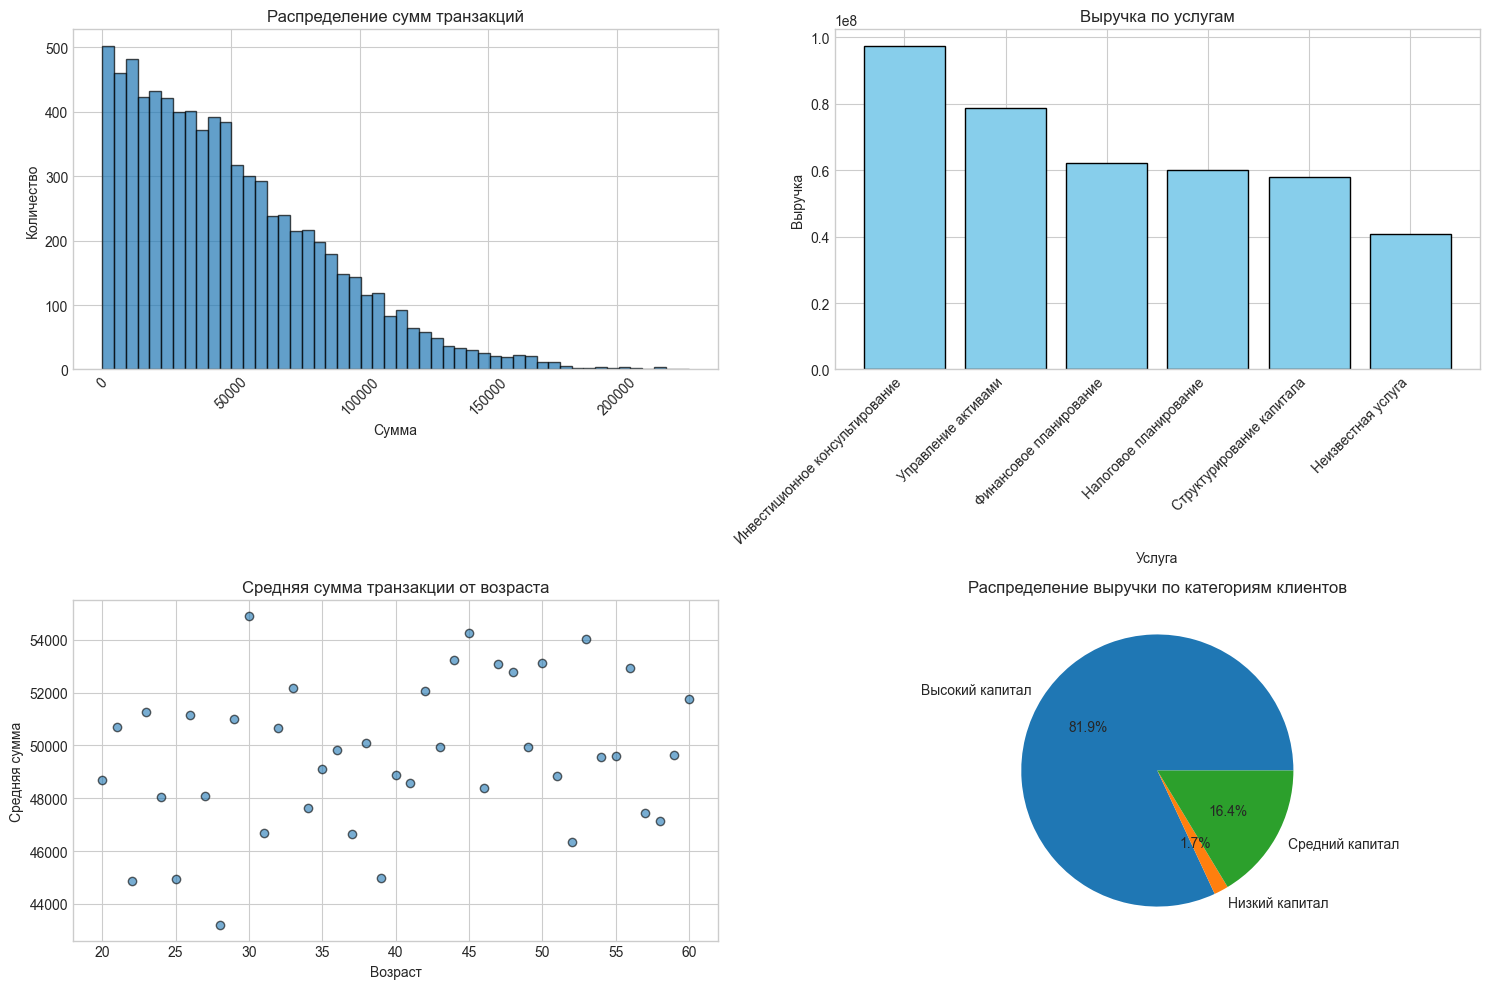

In [21]:
# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(15, 10))

# Распределение сумм транзакций
plt.subplot(2, 2, 1)
plt.hist(df['amount'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Распределение сумм транзакций')
plt.xlabel('Сумма')
plt.ylabel('Количество')
plt.xticks(rotation=45)

# Диаграмма выручки по услугам
plt.subplot(2, 2, 2)
plt.bar(revenue_by_service['service'], revenue_by_service['total_revenue'], color='skyblue', edgecolor='black')
plt.title('Выручка по услугам')
plt.xlabel('Услуга')
plt.ylabel('Выручка')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Зависимость средней суммы транзакции от возраста
plt.subplot(2, 2, 3)
age_amount = df.groupby('age')['amount'].mean().reset_index()
age_amount.columns = ['age', 'avg_amount']
plt.scatter(age_amount['age'], age_amount['avg_amount'], alpha=0.6, edgecolors='black')
plt.title('Средняя сумма транзакции от возраста')
plt.xlabel('Возраст')
plt.ylabel('Средняя сумма')

# Выручка по категориям клиентов
plt.subplot(2, 2, 4)
plt.pie(revenue_by_wealth['total_revenue'], labels=revenue_by_wealth['wealth_category'], autopct='%1.1f%%')
plt.title('Распределение выручки по категориям клиентов')

plt.tight_layout()
plt.show()

Анализ распределения сумм транзакций показывает ярко выраженную правостороннюю асимметрию: большинство операций сосредоточено в диапазоне до 50 тысяч рублей, при этом частота транзакций постепенно снижается по мере роста суммы. Такая структура характерна для финансовых данных и указывает на то, что клиенты предпочитают совершать множество небольших операций, тогда как крупные сделки происходят значительно реже. Длинный хвост распределения, уходящий за 200 тысяч рублей, отражает наличие премиального сегмента транзакций, которые формируют существенную часть общей выручки.

Диаграмма выручки по услугам демонстрирует четкую иерархию востребованности сервисов компании. Лидером является инвестиционное консультирование с выручкой около 100 миллионов рублей, за ним следует управление активами с показателем около 80 миллионов. Финансовое и налоговое планирование занимают средние позиции с результатами 60-65 миллионов рублей. Структурирование капитала и неизвестные услуги показывают наименьшие результаты. Такая структура доходов указывает на то, что клиенты предпочитают комплексные услуги по управлению капиталом, а не разовые консультационные продукты.

График зависимости средней суммы транзакции от возраста клиентов не выявляет выраженной линейной корреляции между этими показателями. Средние суммы колеблются в диапазоне от 44 до 54 тысяч рублей для всех возрастных групп от 20 до 60 лет. Наблюдаются отдельные пики активности около 30 и 45 лет, однако в целом паттерн расходов остается достаточно стабильным across всех возрастов. Это свидетельствует о том, что возраст не является определяющим фактором размера транзакции, и компания успешно работает с клиентами разных поколений.

Распределение выручки по категориям клиентов показывает критическую зависимость бизнеса от клиентов с высоким уровнем капитала, которые генерируют 81.9% всех доходов компании. Клиенты со средним капиталом вносят 16.4% выручки, тогда как сегмент с низким капиталом обеспечивает лишь 1.7%. Такая концентрация доходов создает существенные риски для устойчивости бизнеса, поскольку потеря даже нескольких крупных клиентов может серьезно повлиять на финансовые результаты. С другой стороны, это подтверждает правильность стратегии фокусировки на состоятельной аудитории и указывает на потенциал развития услуг премиум-класса.

### Прогнозирование спроса

Прогноз выручки на следующий месяц: 70,650,993.94
Текущая средняя месячная выручка: 132,278,312.16
Тренд: падение на 30,813,659.11 в месяц


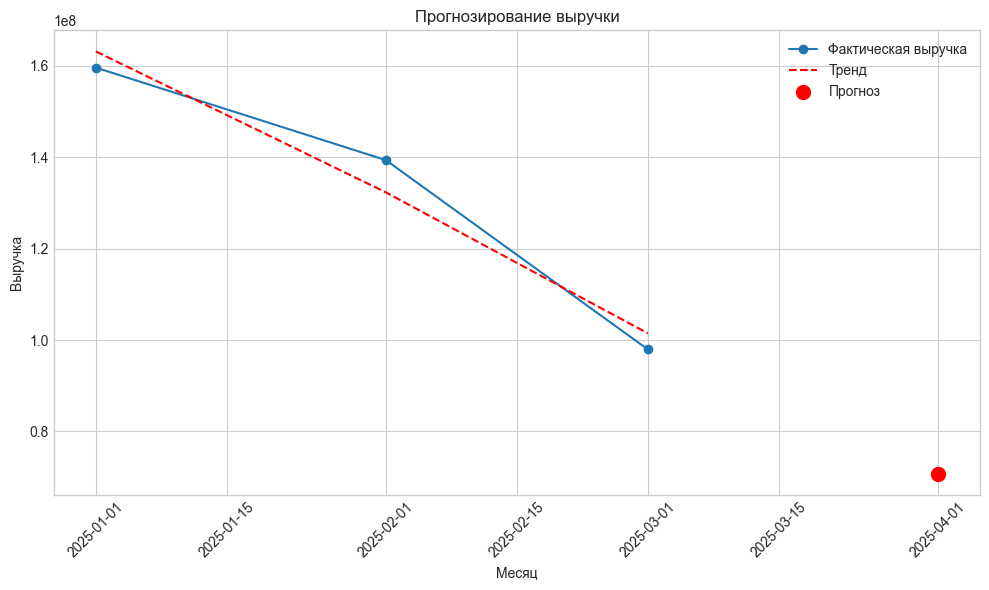

In [22]:
# Группировка по месяцам
df['month'] = df['transaction_date'].dt.to_period('M').apply(lambda r: r.start_time)
monthly_revenue = df.groupby('month')['amount'].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values('month')

# Подготовка данных для модели
X = np.arange(len(monthly_revenue)).reshape(-1, 1)
y = monthly_revenue['amount'].values

# Обучение модели
model = LinearRegression()
model.fit(X, y)

# Прогноз на следующий месяц
next_month = len(monthly_revenue)
forecast = model.predict([[next_month]])[0]

# Вывод результата
print(f"Прогноз выручки на следующий месяц: {forecast:,.2f}")
print(f"Текущая средняя месячная выручка: {monthly_revenue['amount'].mean():,.2f}")
print(f"Тренд: {'рост' if model.coef_[0] > 0 else 'падение'} на {abs(model.coef_[0]):,.2f} в месяц")

# Визуализация прогноза
plt.figure(figsize=(10, 6))
plt.plot(monthly_revenue['month'], monthly_revenue['amount'], marker='o', label='Фактическая выручка')

# Линия тренда
trend = model.predict(X)
plt.plot(monthly_revenue['month'], trend, 'r--', label='Тренд')

# Точка прогноза
next_month_date = monthly_revenue['month'].max() + pd.offsets.MonthEnd(1) + pd.Timedelta(days=1)
plt.scatter([next_month_date], [forecast], color='red', s=100, zorder=5, label='Прогноз')

plt.title('Прогнозирование выручки')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Анализ прогноза выручки выявляет тревожную отрицательную динамику развития бизнеса. Фактическая выручка демонстрирует устойчивое снижение с 160 миллионов рублей в январе до 98 миллионов в марте, что свидетельствует о потере почти 40% доходов за трехмесячный период. Линейный тренд подтверждает систематическое падение с темпом снижения около 30,8 миллиона рублей ежемесячно.

Прогнозная модель на основе линейной регрессии предсказывает дальнейшее ухудшение ситуации: ожидаемая выручка в апреле составит около 70,7 миллиона рублей, что на 47% ниже показателя января и на 28% ниже средней месячной выручки за анализируемый период. Столь резкое падение указывает на наличие серьезных проблем в бизнес-процессах или негативных внешних факторов, требующих немедленного выявления и устранения.

Критическим является то, что прогноз значительно отклоняется от текущей средней выручки в 132 миллиона рублей, что подчеркивает нестабильность бизнес-модели. Компании необходимо срочно разработать и реализовать антикризисные меры: провести анализ причин оттока клиентов, пересмотреть ценовую политику, усилить маркетинговую активность и диверсифицировать продуктовую линейку для стабилизации доходов и разворота негативного тренда.